<a href="https://colab.research.google.com/github/Ethan-Shak/SC3021_SDAB_Group_3/blob/main/SC3021_Group_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [178]:
#All relevant imports for the notebook
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import requests
import datetime
from datetime import datetime
import numpy as np
import scipy.stats as stats
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


# **Which Risk Factors Drive Diabetes Worldwide?**
DADI VENKAT ROHIT, ETHAN SHAK JIN JIE, AND RADINKA SHANMUGANANTHAM

# **HYPOTHESIS**
According to the International Diabetes Federation, approximately 537 million adults aged 20-79 were living with diabetes in 2021, and this number is projected to rise to 783 million by 2045. Even in Singapore, we face a rising type 2 diabetes epidemic with 11.4% prevalence among adults and projections reaching 786,000 by 2050.

Early detection and risk assessment are crucial for prevention and management. This raises an important question on how multi-country health data can improve diabetes risk prediction for our ethnically-diverse population.

In this context, we will explore the possible correlation between different risk factors (metabolic, demographic, lifestyle, and medical) during diabetes prediction across multiple countries. We hypothesize that combining data from geographically and demographically diverse populations will improve model accuracy and help identify the most significant risk factors that drive diabetes internationally.






# **DATA SOURCE IDENTIFICATION AND EXPLORATION**

## **Requirement Analysis:** To tackle the problem, we need to have comprehensive health data about individuals that includes measurements of key diabetes risk factors.

This data needs to be aligned across multiple countries to enable transfer learning. For accurate analysis, it is desirable to have sufficient data on individuals across different demographic groups and geographic regions, requiring a broad coverage of countries. It is sufficient to have one summary entry per individual (no single events in records) because the prediction aims at overall diabetes status. Risk factors vary across populations so we do not need temporal data at fine granularity (day or month may be enough).

The necessary data we will use include well-established risk factors such as age, body mass index (BMI), blood glucose levels etc. This allows the model to capture how long-term health indicators and inherited risk contribute to diabetes development.

Environmental factors are excluded from this study, as the focus is placed on personal health metrics and clinical indicators that are directly measurable and actionable. Thus increasing the robustness of our data analysis.


**List of considered sources:**

We researched several sources to have as varied populations as possible from different countries.

India https://www.kaggle.com/datasets/ankushpanday1/diabetes-prediction-in-india-dataset

Bangladesh https://www.kaggle.com/datasets/abdelazizsami/early-stage-diabetes-risk-prediction

USA BRFSS
https://www.kaggle.com/datasets/alexteboul/diabetes-health-indicators-dataset

Indonesia
https://www.kaggle.com/datasets/iammustafatz/diabetes-prediction-dataset

Pima Indians https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database

USA NHANES https://www.kaggle.com/datasets/cdc/national-health-and-nutrition-examination-survey

## **Dataset 1: India diabetes dataset**

This dataset contains 5,292 anonymised health records from individuals in India, with 27 demographic, lifestyle, and clinical attributes designed to support prediction of diabetes

In [113]:
df_india = pd.read_csv('/content/drive/MyDrive/SC3021/diabetes_prediction_india.csv')
print(df_india.head())

   Age  Gender   BMI Family_History Physical_Activity       Diet_Type  \
0   48    Male  35.5             No              High  Non-Vegetarian   
1   18   Other  28.7            Yes            Medium  Non-Vegetarian   
2   21   Other  30.0            Yes              High  Non-Vegetarian   
3   25  Female  25.6             No            Medium      Vegetarian   
4   78    Male  38.8             No              High  Non-Vegetarian   

  Smoking_Status Alcohol_Intake Stress_Level Hypertension  ...  \
0          Never            NaN       Medium          Yes  ...   
1        Current       Moderate         High           No  ...   
2        Current       Moderate         High          Yes  ...   
3         Former       Moderate         High          Yes  ...   
4        Current           High         High           No  ...   

   Health_Insurance  Regular_Checkups  Medication_For_Chronic_Conditions  \
0                No                No                                 No   
1           

**Comments on the data set for India**

This dataset looks at diabetes risk in the Indian population using a combination of personal, lifestyle, and health-related factors. It also includes information such as diet type, physical activity, smoking, stress level, and regular health checkups, which can help show how daily habits and existing health conditions may be linked to diabetes status.

However some variables may be based on self-reported information, which can affect accuracy.

## **Dataset 2: Bangladesh diabetes dataset**

This dataset contains sign and symptom data of newly diabetic or at‑risk patients, collected via questionnaire at Sylhet Diabetes Hospital in Bangladesh.

In [114]:
df_bangladesh = pd.read_csv('/content/drive/MyDrive/SC3021/bangladesh_diabetes.csv')
print(df_bangladesh.head())

   Age Gender Polyuria Polydipsia sudden weight loss weakness Polyphagia  \
0   40   Male       No        Yes                 No      Yes         No   
1   58   Male       No         No                 No      Yes         No   
2   41   Male      Yes         No                 No      Yes        Yes   
3   45   Male       No         No                Yes      Yes        Yes   
4   60   Male      Yes        Yes                Yes      Yes        Yes   

  Genital thrush visual blurring Itching Irritability delayed healing  \
0             No              No     Yes           No             Yes   
1             No             Yes      No           No              No   
2             No              No     Yes           No             Yes   
3            Yes              No     Yes           No             Yes   
4             No             Yes     Yes          Yes             Yes   

  partial paresis muscle stiffness Alopecia Obesity     class  
0              No              Yes      

**Comments on the data set for Bangladesh**

This dataset, collected from patients at Sylhet Diabetes Hospital in Sylhet, Bangladesh, focuses on the signs and symptoms of newly diagnosed diabetic patients or those at risk of developing diabetes. By emphasizing early warning signs rather than lab results, it enables identification of at-risk individuals before clinical diagnosis. The inclusion of less common symptoms like genital thrush and partial paresis may reveal interesting patterns, though self-reported data could introduce bias and lifestyle factors such as diet or exercise are not included. The dataset is intended for predicting the likelihood of diabetes at an early stage using data mining techniques.

## Dataset 3: USA BRFSS diabetes dataset

This dataset aggregates 253k+ BRFSS 2015 survey responses in the USA, including lifestyle, comorbidities, and health indicators, and includes a diabetes label derived from survey responses.

In [115]:
df_USA_BRFSS = pd.read_csv('/content/drive/MyDrive/SC3021/AMERICAA_diabetes.csv')
print(df_USA_BRFSS.head())

   Diabetes_binary  HighBP  HighChol  CholCheck   BMI  Smoker  Stroke  \
0              0.0     1.0       1.0        1.0  40.0     1.0     0.0   
1              0.0     0.0       0.0        0.0  25.0     1.0     0.0   
2              0.0     1.0       1.0        1.0  28.0     0.0     0.0   
3              0.0     1.0       0.0        1.0  27.0     0.0     0.0   
4              0.0     1.0       1.0        1.0  24.0     0.0     0.0   

   HeartDiseaseorAttack  PhysActivity  Fruits  ...  AnyHealthcare  \
0                   0.0           0.0     0.0  ...            1.0   
1                   0.0           1.0     0.0  ...            0.0   
2                   0.0           0.0     1.0  ...            1.0   
3                   0.0           1.0     1.0  ...            1.0   
4                   0.0           1.0     1.0  ...            1.0   

   NoDocbcCost  GenHlth  MentHlth  PhysHlth  DiffWalk  Sex   Age  Education  \
0          0.0      5.0      18.0      15.0       1.0  0.0   9.0   

**Comments on the data set for USA BRFSS**

This dataset comes from the 2015 Behavioral Risk Factor Surveillance System, which includes information on clinical factors, lifestyle behaviors, mental and physical health, and socioeconomic background, allowing for a wide-ranging analysis of diabetes risk.

The data also covers access to healthcare and preventive services, which makes it possible to explore health disparities. With three categories of diabetes no diabetes, prediabetes, and diabetes the dataset supports detailed modeling and helps identify early warning signs of the disease.


## Dataset 4: Indonesia diabetes dataset

This dataset contains 100,000 de‑identified patient records with demographic and clinical variables

In [116]:
df_Indonesia = pd.read_csv('/content/drive/MyDrive/SC3021/Indonesia_diabetes_prediction_dataset.csv')
print(df_Indonesia.head())

   gender   age  hypertension  heart_disease smoking_history    bmi  \
0  Female  80.0             0              1           never  25.19   
1  Female  54.0             0              0         No Info  27.32   
2    Male  28.0             0              0           never  27.32   
3  Female  36.0             0              0         current  23.45   
4    Male  76.0             1              1         current  20.14   

   HbA1c_level  blood_glucose_level  diabetes  
0          6.6                  140         0  
1          6.6                   80         0  
2          5.7                  158         0  
3          5.0                  155         0  
4          4.8                  155         0  


**Comments on the data set for Indonesia**

This Indonesia diabetes dataset contains individual-level records and includes key risk factors such as age, BMI, HbA1c level, blood glucose level, as well as hypertension, heart disease, gender, and smoking history.


The target variable diabetes is binary (0/1), making it suitable for supervised classification to estimate diabetes risk.

## **Dataset 5: Pima Indians diabetes dataset**

This dataset contains medical measurements of female Pima Indian patients aged ≥21 years from the National Institute of Diabetes and Digestive and Kidney Diseases.

In [117]:
df_pima = pd.read_csv('/content/drive/MyDrive/SC3021/pima_indians_diabetes.csv')
print(df_pima.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


**Comments on the data set for Pima Indians**

This dataset focuses on a specific population, Pima Indian heritage with high diabetes prevalence, making it valuable for studying genetic predisposition. The diabetes pedigree function is a unique feature that quantifies family history using a specialized algorithm.

However, the dataset only includes females aged 21+, which limits generalizability. The glucose tolerance test results provide clinical-grade measurements that could be strong predictors.

## **Dataset 6: USA NHANES diabetes dataset**

This dataset contains official NHANES survey data from the CDC, combining interviews, physical exams, and laboratory tests on ~10,000 US participants per 2-year cycle to assess health/nutrition status across diverse ethnicities.


In [169]:
from functools import reduce

#Load the relevant CSV files
df_demo = pd.read_csv('/content/drive/MyDrive/SC3021/NHANES_demographic.csv')
df_exam = pd.read_csv('/content/drive/MyDrive/SC3021/NHANES_examination.csv')
df_labs = pd.read_csv('/content/drive/MyDrive/SC3021/NHANES_labs.csv')
df_quest = pd.read_csv('/content/drive/MyDrive/SC3021/NHANES_questionnaire.csv')

#Selected only the columns relevant to diabetes factors
demo_cols  = ['SEQN', 'RIDAGEYR', 'RIAGENDR']
exam_cols  = ['SEQN', 'BMXBMI', 'BPXSY1', 'BPXDI1']
labs_cols  = ['SEQN', 'LBXTC']
quest_cols = ['SEQN', 'DIQ010', 'MCQ160C', 'MCQ160E', 'SMQ040',
              'BPQ050A', 'BPQ080', 'PAQ605', 'PAQ650', 'PAQ620']

df_demo = df_demo[demo_cols]
df_exam = df_exam[exam_cols]
df_labs = df_labs[labs_cols]
df_quest = df_quest[quest_cols]
dataframes = [df_demo, df_exam, df_labs, df_quest]

# Inner Join of all dataframes on 'SEQN'
df_USA_NHANES = reduce(lambda left, right: pd.merge(left, right, on='SEQN', how='inner'), dataframes)

rename_dict = {
    'SEQN': 'patient_id',
    'RIDAGEYR': 'age_years',
    'RIAGENDR': 'gender_code',
    'BMXBMI': 'bmi',
    'BPXSY1': 'systolic_bp',
    'BPXDI1': 'diastolic_bp',
    'LBXTC': 'total_cholesterol',
    'DIQ010': 'diabetes_status',
    'MCQ160C': 'coronary_heart_disease',
    'MCQ160E': 'heart_attack',
    'SMQ040': 'current_smoker_status',
    'BPQ050A': 'taking_bp_meds',
    'BPQ080': 'taking_cholesterol_meds',
    'PAQ605': 'vigorous_work_activity',
    'PAQ650': 'vigorous_recreational_activity',
    'PAQ620': 'moderate_work_activity'
}

existing_renames = {k: v for k, v in rename_dict.items() if k in df_USA_NHANES.columns}
df_USA_NHANES.rename(columns=existing_renames, inplace=True)

print(df_USA_NHANES.head())

   patient_id  age_years  gender_code   bmi  systolic_bp  diastolic_bp  \
0       73557         69            1  26.7        122.0          72.0   
1       73558         54            1  28.6        156.0          62.0   
2       73559         72            1  28.9        140.0          90.0   
3       73560          9            1  17.1        108.0          38.0   
4       73561         73            2  19.7        136.0          86.0   

   total_cholesterol  diabetes_status  coronary_heart_disease  heart_attack  \
0              167.0              1.0                     2.0           2.0   
1              170.0              1.0                     2.0           2.0   
2              126.0              1.0                     2.0           2.0   
3              168.0              2.0                     NaN           NaN   
4              201.0              2.0                     2.0           2.0   

   current_smoker_status  taking_bp_meds  taking_cholesterol_meds  \
0          

**Comments on the data set for USA NHANES**

This dataset from the CDC's National Health and Nutrition Examination Survey is unique as it combines self-reported questionnaire responses with objective, gold-standard laboratory tests and physical examinations (such as clinician-measured blood pressure, HbA1c, and BMI).

By integrating clinical accuracy with broad lifestyle data across a nationally representative, multi-ethnic US sample, it significantly reduces the recall bias often found in pure survey datasets.

However, because it is aggregated across multiple distinct survey modules, it requires complex structuring to derive standardized binary health indicators for integration.

# **EXPLORATION OF DATA QUALITY**

## **India Dataset Profiling**

### **Dimensions and Attributes**  
  
We check how many rows (observations) and list out columns (attributes) which are in the dataset to get a sense of its scale and complexity.

In [119]:
num_rows = df_india.shape[0]
num_cols = df_india.shape[1]
print(f"Number of rows: {num_rows}")
print(f"Number of columns: {num_cols}")
print("\nDataset Columns:")
for col in df_india.columns:
    print("-", col)

Number of rows: 5292
Number of columns: 27

Dataset Columns:
- Age
- Gender
- BMI
- Family_History
- Physical_Activity
- Diet_Type
- Smoking_Status
- Alcohol_Intake
- Stress_Level
- Hypertension
- Cholesterol_Level
- Fasting_Blood_Sugar
- Postprandial_Blood_Sugar
- HBA1C
- Heart_Rate
- Waist_Hip_Ratio
- Urban_Rural
- Health_Insurance
- Regular_Checkups
- Medication_For_Chronic_Conditions
- Pregnancies
- Polycystic_Ovary_Syndrome
- Glucose_Tolerance_Test_Result
- Vitamin_D_Level
- C_Protein_Level
- Thyroid_Condition
- Diabetes_Status


### **Missing/NULL values**

We check for missing data that might need imputation (mean, median, mode) or removal depending on severity and feature importance.

In [120]:
print(f"This dataset contains missing/NULL values: {df_USA_BRFSS.isnull().any().any()}")
missing_values = df_india.isnull().sum()
print("Missing values per column:\n", missing_values[missing_values > 0])

This dataset contains missing/NULL values: False
Missing values per column:
 Alcohol_Intake    1780
dtype: int64


### **Data types**
It includes a mix of binary variables and continuous clinical measures.

Many columns are categorical "Yes/No" formats that require mapping to binary (0/1) for modeling.

We can also convert these into numeric or categorical types for easier analysis and modeling.

In [121]:
print("Data types before conversion:")
display(df_india.dtypes)
# Convert categorical yes/no columns to binary (0 = No, 1 = Yes)
yes_no_cols = ['Family_History', 'Hypertension', 'Health_Insurance',
               'Regular_Checkups', 'Medication_For_Chronic_Conditions',
               'Polycystic_Ovary_Syndrome', 'Thyroid_Condition', 'Diabetes_Status']
for col in yes_no_cols:
    df_india[col] = df_india[col].map({'No': 0, 'Yes': 1})
# Convert categorical columns to categorical dtype
cat_cols = ['Gender', 'Diet_Type', 'Physical_Activity', 'Smoking_Status', 'Alcohol_Intake', 'Stress_Level', 'Urban_Rural']
for col in cat_cols:
    df_india[col] = df_india[col].astype('category')
print("\nData types after conversion:")
display(df_india.dtypes)

Data types before conversion:


,0
Age,int64
Gender,object
BMI,float64
Family_History,object
Physical_Activity,object
Diet_Type,object
Smoking_Status,object
Alcohol_Intake,object
Stress_Level,object
Hypertension,object



Data types after conversion:


,0
Age,int64
Gender,category
BMI,float64
Family_History,int64
Physical_Activity,category
Diet_Type,category
Smoking_Status,category
Alcohol_Intake,category
Stress_Level,category
Hypertension,int64


### **Class Balance for Target variable**

We visualize the target variable (Diabetes_Status) using a bar and pie chart to examine class imbalance. In this case, resampling is not required as the distribution is sufficiently balanced.

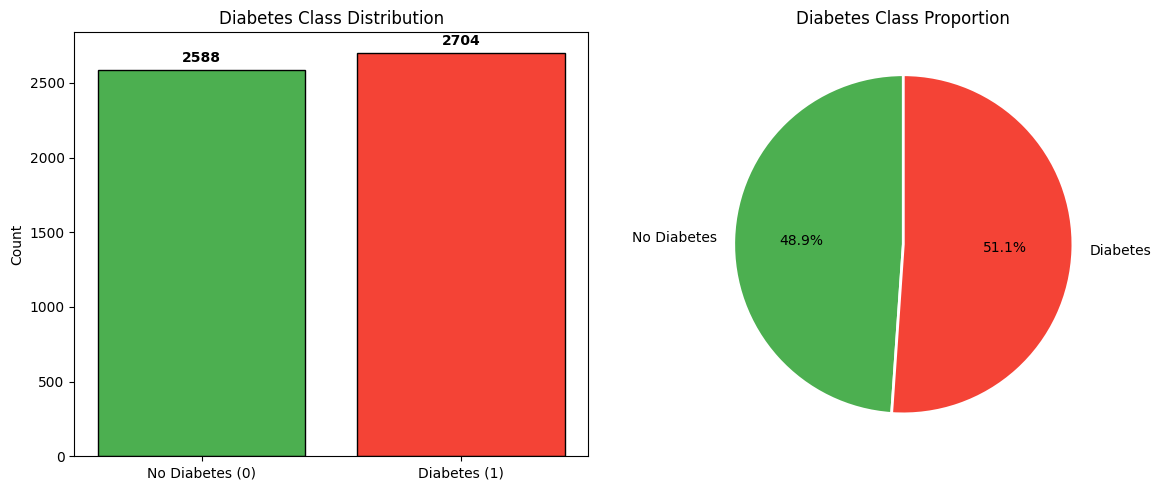

In [122]:
# Check distribution of target variable (Diabetes_Status)
vc = df_india['Diabetes_Status'].value_counts()
# Bar and pie plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# Bar chart
bars = axes[0].bar(['No Diabetes (0)', 'Diabetes (1)'],
                   [vc.get(0, 0), vc.get(1, 0)],
                   color=['#4CAF50', '#F44336'], edgecolor='black')
axes[0].set_title('Diabetes Class Distribution')
axes[0].set_ylabel('Count')
for bar, val in zip(bars, [vc.get(0, 0), vc.get(1, 0)]):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 50, val, ha='center', fontweight='bold')
# Pie chart
axes[1].pie([vc.get(0, 0), vc.get(1, 0)],
            labels=['No Diabetes', 'Diabetes'],
            colors=['#4CAF50', '#F44336'], autopct='%1.1f%%',
            wedgeprops={'edgecolor': 'white', 'linewidth': 2}, startangle=90)
axes[1].set_title('Diabetes Class Proportion')
plt.tight_layout()
plt.show()

### **Exploration of Variables**

We use histograms to see how numerical measures like BMI, glucose levels, or HbA1c are distributed.

We visualise the proportion of binary health indicators like hypertension or thyroid via bar charts.

We use these to identify any extreme values, skewness, and potential outliers

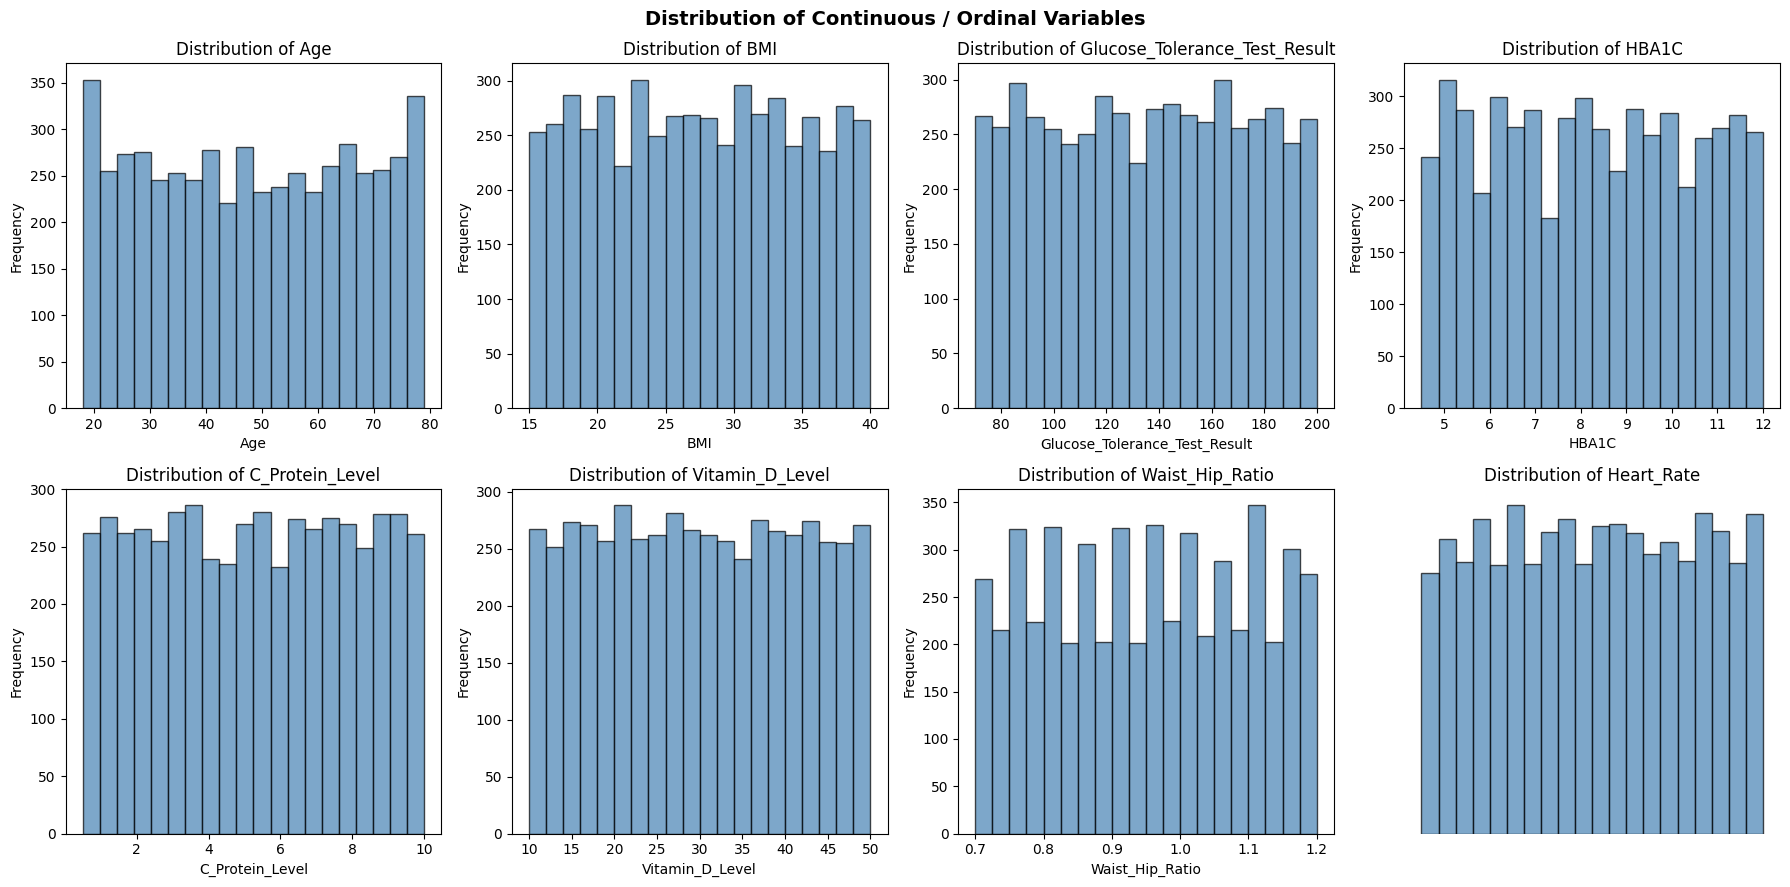

In [123]:
continuous_cols = ['Age', 'BMI', 'Glucose_Tolerance_Test_Result', 'HBA1C',
                   'C_Protein_Level', 'Vitamin_D_Level', 'Waist_Hip_Ratio', 'Heart_Rate']
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()
for i, col in enumerate(continuous_cols):
    axes[i].hist(df_india[col].dropna(), bins=20, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
axes[-1].axis('off')
plt.suptitle('Distribution of Continuous / Ordinal Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

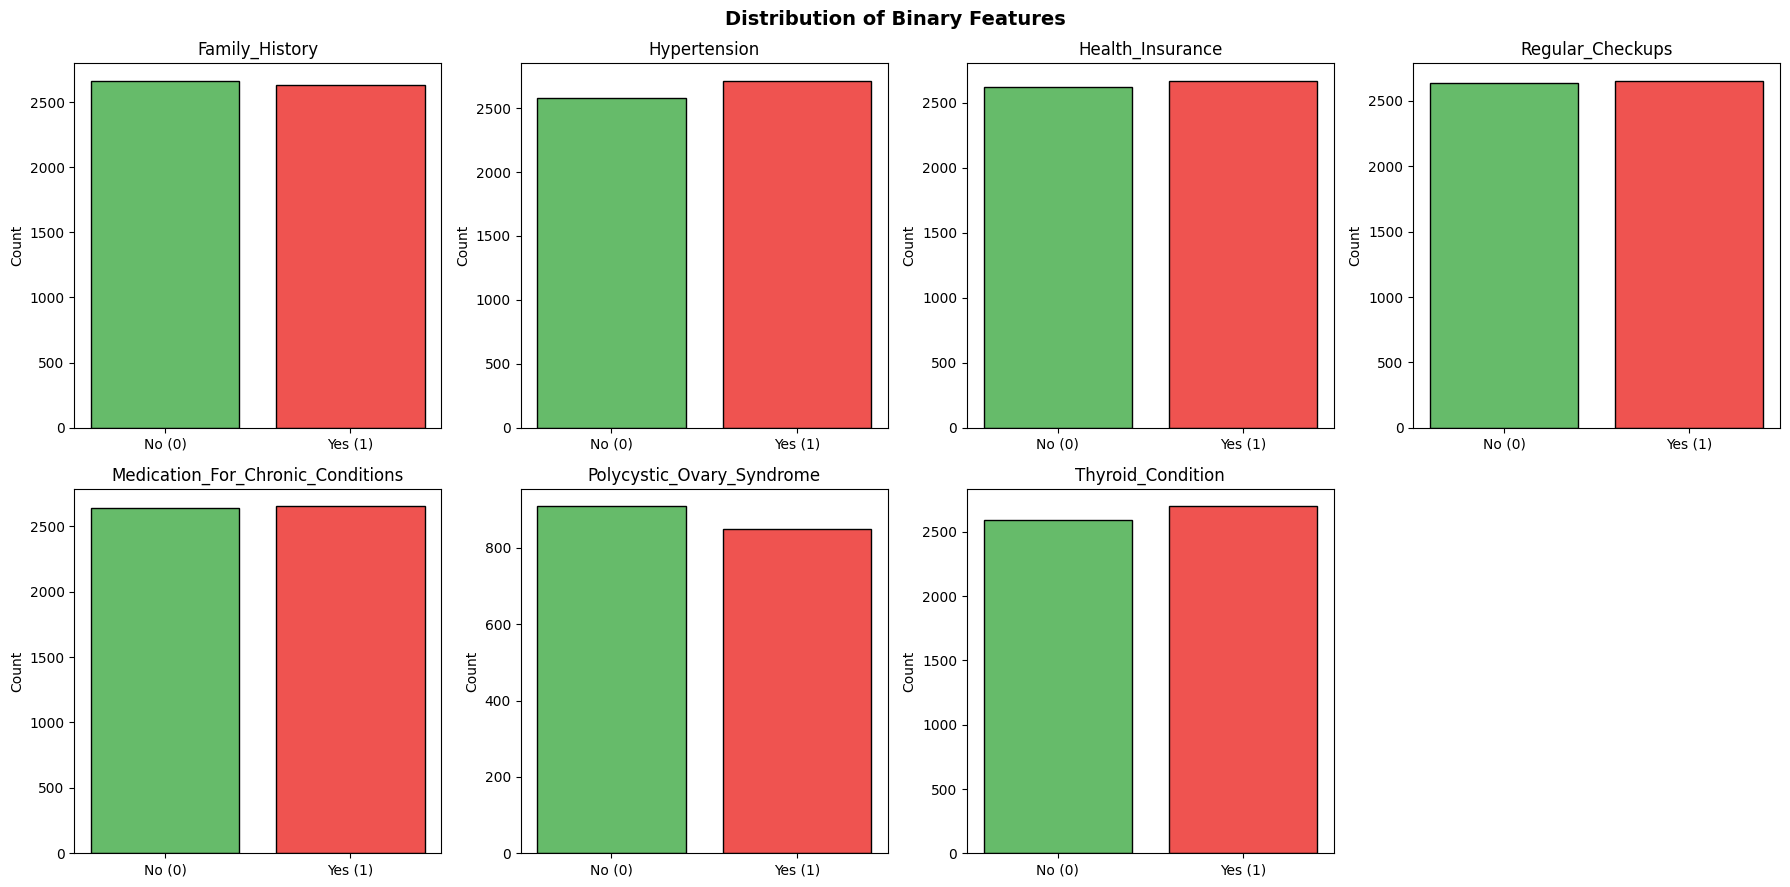

In [124]:
binary_cols = ['Family_History', 'Hypertension', 'Health_Insurance',
               'Regular_Checkups', 'Medication_For_Chronic_Conditions',
               'Polycystic_Ovary_Syndrome', 'Thyroid_Condition']
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()
for i, col in enumerate(binary_cols):
    counts = df_india[col].value_counts()
    axes[i].bar(['No (0)', 'Yes (1)'],
                [counts.get(0, 0), counts.get(1, 0)],
                color=['#66BB6A', '#EF5350'], edgecolor='black')
    axes[i].set_title(col)
    axes[i].set_ylabel('Count')
for j in range(len(binary_cols), len(axes)):
    axes[j].axis('off')
plt.suptitle('Distribution of Binary Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## **Bangladesh Dataset Profiling**

### **Dimensions and Attributes**  
  
We check how many rows (observations) and list out columns (attributes) which are in the dataset to get a sense of its scale and complexity. This is a very small dataset with 520 rows and 17 columns.

In [125]:
num_rows = df_bangladesh.shape[0]
num_cols = df_bangladesh.shape[1]
print(f"Number of rows: {num_rows}")
print(f"Number of columns: {num_cols}")
print("\nDataset Columns:")
for col in df_bangladesh.columns:
    print("-", col)

Number of rows: 520
Number of columns: 17

Dataset Columns:
- Age
- Gender
- Polyuria
- Polydipsia
- sudden weight loss
- weakness
- Polyphagia
- Genital thrush
- visual blurring
- Itching
- Irritability
- delayed healing
- partial paresis
- muscle stiffness
- Alopecia
- Obesity
- class


### **Missing/NULL values**

We check for missing data that might need imputation (mean, median, mode) or removal depending on severity and feature importance.

In [126]:
print(f"This dataset contains missing/NULL values: {df_bangladesh.isnull().any().any()}")
print(f"No missing values were detected so no imputation is required")

This dataset contains missing/NULL values: False
No missing values were detected so no imputation is required


### **Data types**
It relies almost entirely on self-reported, qualitative symptoms (e.g., Polyuria, Polydipsia, sudden weight loss) rather than clinical lab results.

Age is the only continuous variable while the rest are binary categorical symptoms.

In [127]:
print("Data types before conversion:")
display(df_bangladesh.dtypes)

# Convert target 'class' to binary
df_bangladesh['class'] = df_bangladesh['class'].map({'Negative': 0, 'Positive': 1})

# Convert Yes/No symptom columns to binary (0 = No, 1 = Yes)
yes_no_cols = ['Polyuria', 'Polydipsia', 'sudden weight loss', 'weakness',
               'Polyphagia', 'Genital thrush', 'visual blurring', 'Itching',
               'Irritability', 'delayed healing', 'partial paresis',
               'muscle stiffness', 'Alopecia', 'Obesity']
for col in yes_no_cols:
    df_bangladesh[col] = df_bangladesh[col].map({'No': 0, 'Yes': 1})

# Convert Gender to category
df_bangladesh['Gender'] = df_bangladesh['Gender'].astype('category')

print("\nData types after conversion:")
display(df_bangladesh.dtypes)


Data types before conversion:


,0
Age,int64
Gender,object
Polyuria,object
Polydipsia,object
sudden weight loss,object
weakness,object
Polyphagia,object
Genital thrush,object
visual blurring,object
Itching,object



Data types after conversion:


,0
Age,int64
Gender,category
Polyuria,int64
Polydipsia,int64
sudden weight loss,int64
weakness,int64
Polyphagia,int64
Genital thrush,int64
visual blurring,int64
Itching,int64


### **Class Balance for Target variable**

We visualize the target variable (class) using a bar and pie chart to examine class imbalance. In this case, the target is heavily symptom-driven, and shows a noticeable imbalance.

However, this is expected given the dataset was collected at a diabetes hospital specifically from newly diagnosed patients or those already presenting with risk factors.

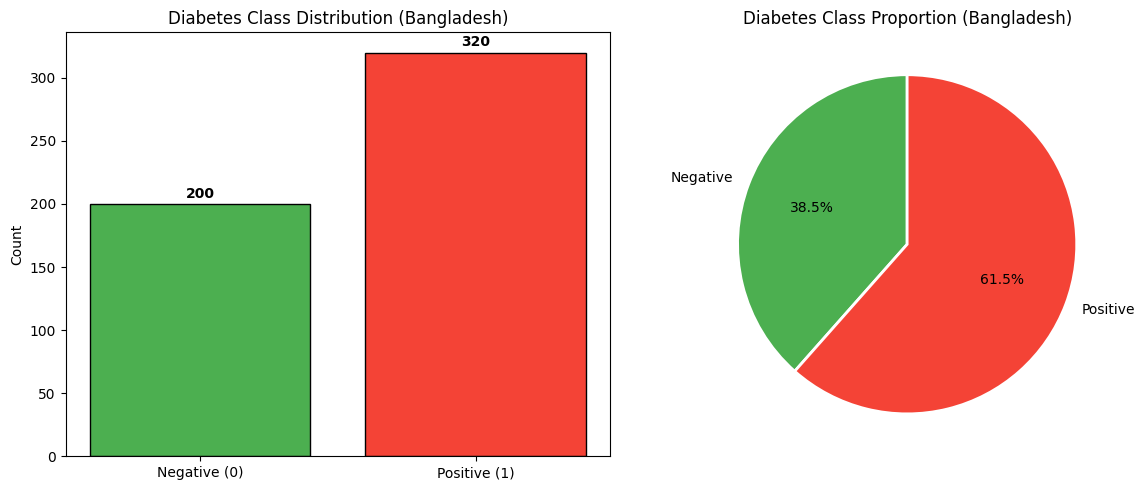

In [128]:
vc = df_bangladesh['class'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
bars = axes[0].bar(['Negative (0)', 'Positive (1)'],
                   [vc.get(0, 0), vc.get(1, 0)],
                   color=['#4CAF50', '#F44336'], edgecolor='black')
axes[0].set_title('Diabetes Class Distribution (Bangladesh)')
axes[0].set_ylabel('Count')
for bar, val in zip(bars, [vc.get(0, 0), vc.get(1, 0)]):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 5, val, ha='center', fontweight='bold')

# Pie chart
axes[1].pie([vc.get(0, 0), vc.get(1, 0)],
            labels=['Negative', 'Positive'],
            colors=['#4CAF50', '#F44336'], autopct='%1.1f%%',
            wedgeprops={'edgecolor': 'white', 'linewidth': 2}, startangle=90)
axes[1].set_title('Diabetes Class Proportion (Bangladesh)')
plt.tight_layout()
plt.show()

### **Exploration of Variables**

We use histograms to see how numerical measures like (insert attribute names) are distributed.

We visualise the proportion of binary health indicators like (insert attribute names) via bar charts.

We use these to identify any extreme values, skewness, and potential outliers

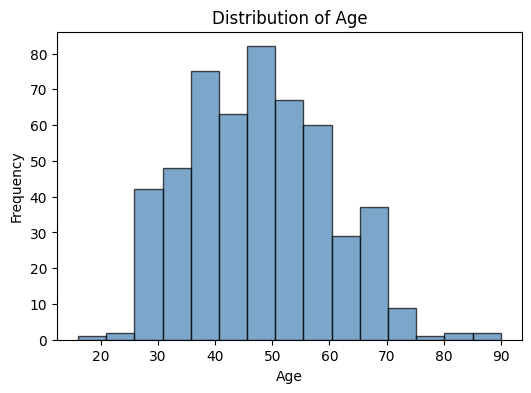

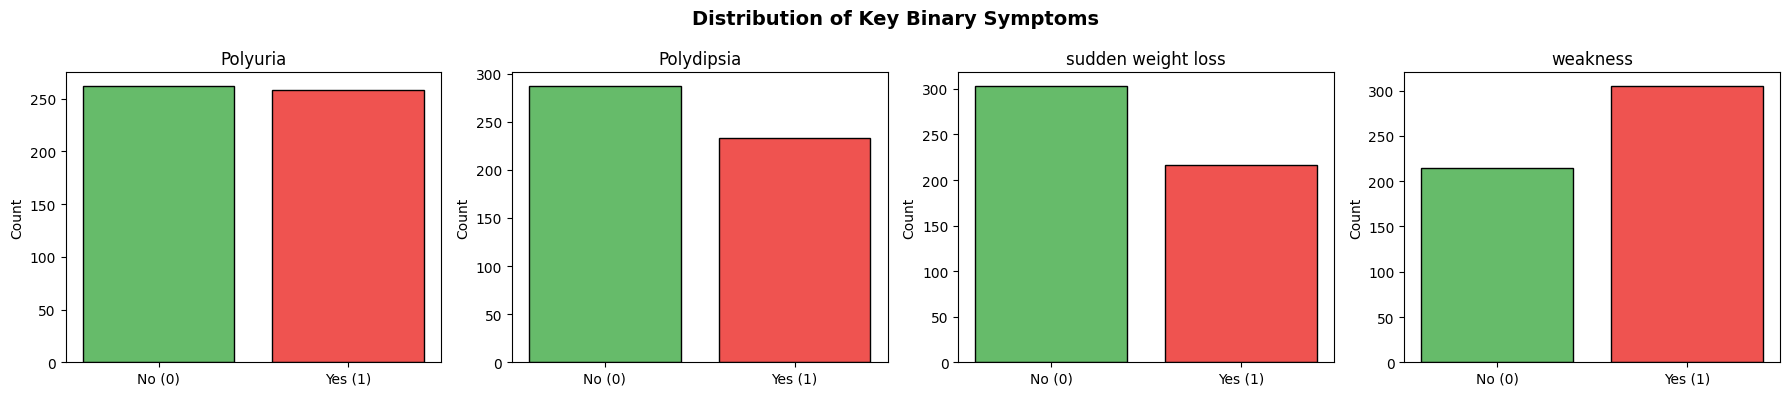

In [129]:
# Only Age is continuous in this dataset as mentioned in data type
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(df_bangladesh['Age'].dropna(), bins=15, color='steelblue', edgecolor='black', alpha=0.7)
ax.set_title('Distribution of Age')
ax.set_xlabel('Age')
ax.set_ylabel('Frequency')
plt.show()

# Plot key binary symptoms
key_symptoms = ['Polyuria', 'Polydipsia', 'sudden weight loss', 'weakness']
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
axes = axes.flatten()
for i, col in enumerate(key_symptoms):
    counts = df_bangladesh[col].value_counts()
    axes[i].bar(['No (0)', 'Yes (1)'],
                [counts.get(0, 0), counts.get(1, 0)],
                color=['#66BB6A', '#EF5350'], edgecolor='black')
    axes[i].set_title(col)
    axes[i].set_ylabel('Count')
plt.suptitle('Distribution of Key Binary Symptoms', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## **USA BRFSS Dataset Profiling**

### **Dimensions and Attributes**  
  
We check how many rows (observations) and list out columns (attributes) which are in the dataset to get a sense of its scale and complexity.

In [130]:
num_rows = df_USA_BRFSS.shape[0]
num_cols = df_USA_BRFSS.shape[1]
print(f"Number of rows: {num_rows}")
print(f"Number of columns: {num_cols}")
print(f"\nDataset Columns:")
for i in df_USA_BRFSS.columns:
  print("- "+ i)

Number of rows: 253680
Number of columns: 22

Dataset Columns:
- Diabetes_binary
- HighBP
- HighChol
- CholCheck
- BMI
- Smoker
- Stroke
- HeartDiseaseorAttack
- PhysActivity
- Fruits
- Veggies
- HvyAlcoholConsump
- AnyHealthcare
- NoDocbcCost
- GenHlth
- MentHlth
- PhysHlth
- DiffWalk
- Sex
- Age
- Education
- Income


### **Missing/NULL values**

We check for missing data that might need imputation (mean, median, mode) or removal depending on severity and feature importance.

In [131]:
print(f"This dataset contains missing/NULL values: {df_USA_BRFSS.isnull().any().any()}")
print(f"No missing values were detected so no imputation is required")

This dataset contains missing/NULL values: False
No missing values were detected so no imputation is required


Initial programmatic checks may flag this dataset as complete. However, survey-based datasets frequently utilize dummy values (such as "None", "Refused", or "Don't Know") to represent missing answers in categorical columns.

These semantic missing values must be identified and corrected during the data cleaning stage to prevent models from learning erroneous patterns.

### **Data types**
All columns are currently float64, but most are binary (0/1) or categorical integers.

We convert them to integer types since decimal points are not meaningful for these columns.

In [132]:
print("Data types before conversion:")
display(df_USA_BRFSS.dtypes)

# Convert all columns to int instead of float
for col in df_USA_BRFSS.columns:
    df_USA_BRFSS[col] = df_USA_BRFSS[col].astype(int)

print("\nData types after conversion:")
display(df_USA_BRFSS.dtypes)


Data types before conversion:


,0
Diabetes_binary,float64
HighBP,float64
HighChol,float64
CholCheck,float64
BMI,float64
Smoker,float64
Stroke,float64
HeartDiseaseorAttack,float64
PhysActivity,float64
Fruits,float64



Data types after conversion:


,0
Diabetes_binary,int64
HighBP,int64
HighChol,int64
CholCheck,int64
BMI,int64
Smoker,int64
Stroke,int64
HeartDiseaseorAttack,int64
PhysActivity,int64
Fruits,int64


### **Class Balance for Target variable**

We visualize the target variable (Diabetes_Status) using a bar and pie chart to examine class imbalance. In this case, the dataset is imbalanced, with 86.1% non-diabetic and 13.9% diabetic cases.

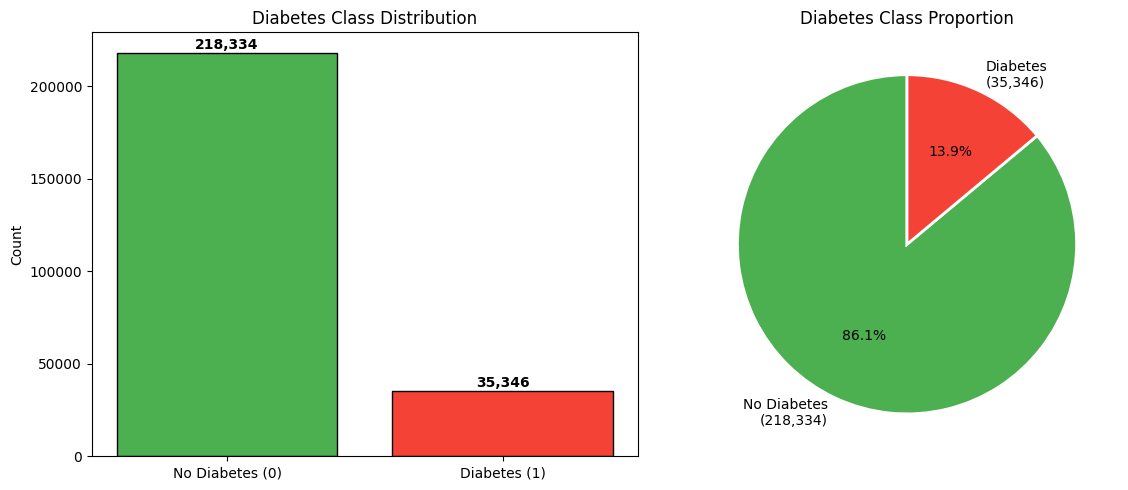

In [133]:
vc = df_USA_BRFSS['Diabetes_binary'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
bars = axes[0].bar(['No Diabetes (0)', 'Diabetes (1)'], [vc[0], vc[1]],
                    color=['#4CAF50', '#F44336'], edgecolor='black')
axes[0].set_ylabel('Count')
axes[0].set_title('Diabetes Class Distribution')
for bar, val in zip(bars, [vc[0], vc[1]]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2000,
                 f'{val:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie([vc[0], vc[1]],
            labels=[f'No Diabetes\n({vc[0]:,})', f'Diabetes\n({vc[1]:,})'],
            colors=['#4CAF50', '#F44336'], autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Diabetes Class Proportion')

plt.tight_layout()
plt.show()

### **Exploration of Variables**

We use histograms to examine the distribution of continuous and ordinal variables like BMI, Age, Physical Health are distributed.

We visualise the proportion of the majority binary attributes to understand how common each health condition or behaviour is in the surveyed population. For example, we can see that 43% of respondents have high blood pressure and 44% are smokers.

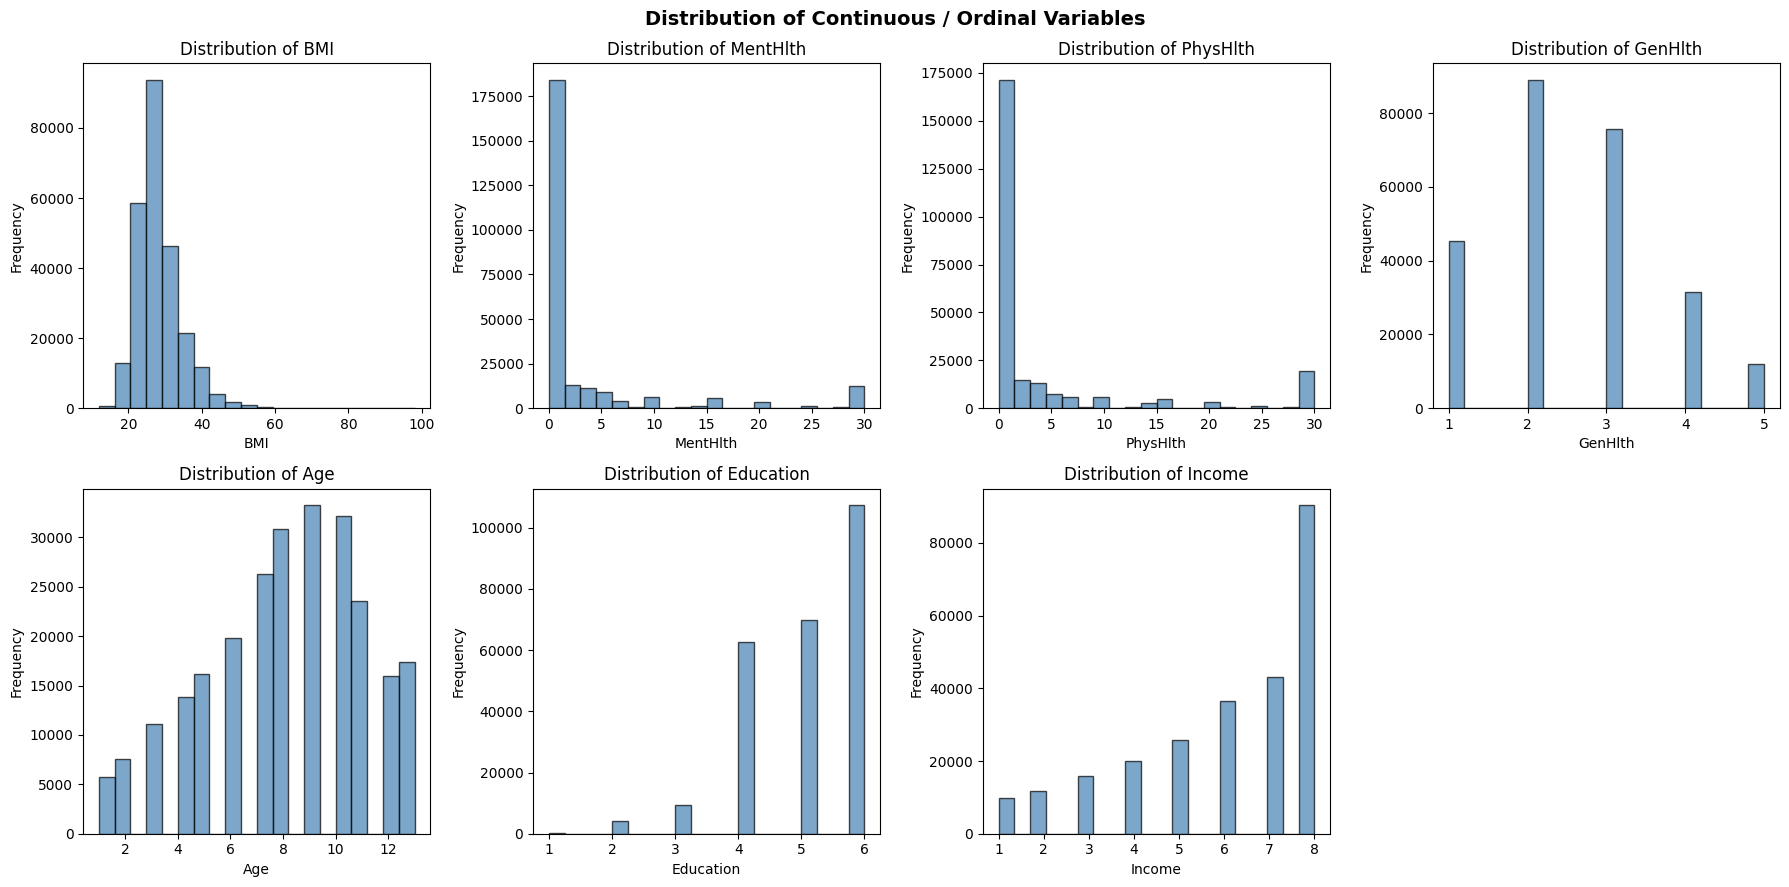

In [134]:
continuous_cols = ['BMI', 'MentHlth', 'PhysHlth', 'GenHlth', 'Age', 'Education', 'Income']

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(continuous_cols):
    axes[i].hist(df_USA_BRFSS[col].dropna(), bins=20, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

axes[-1].axis('off')
plt.suptitle('Distribution of Continuous / Ordinal Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

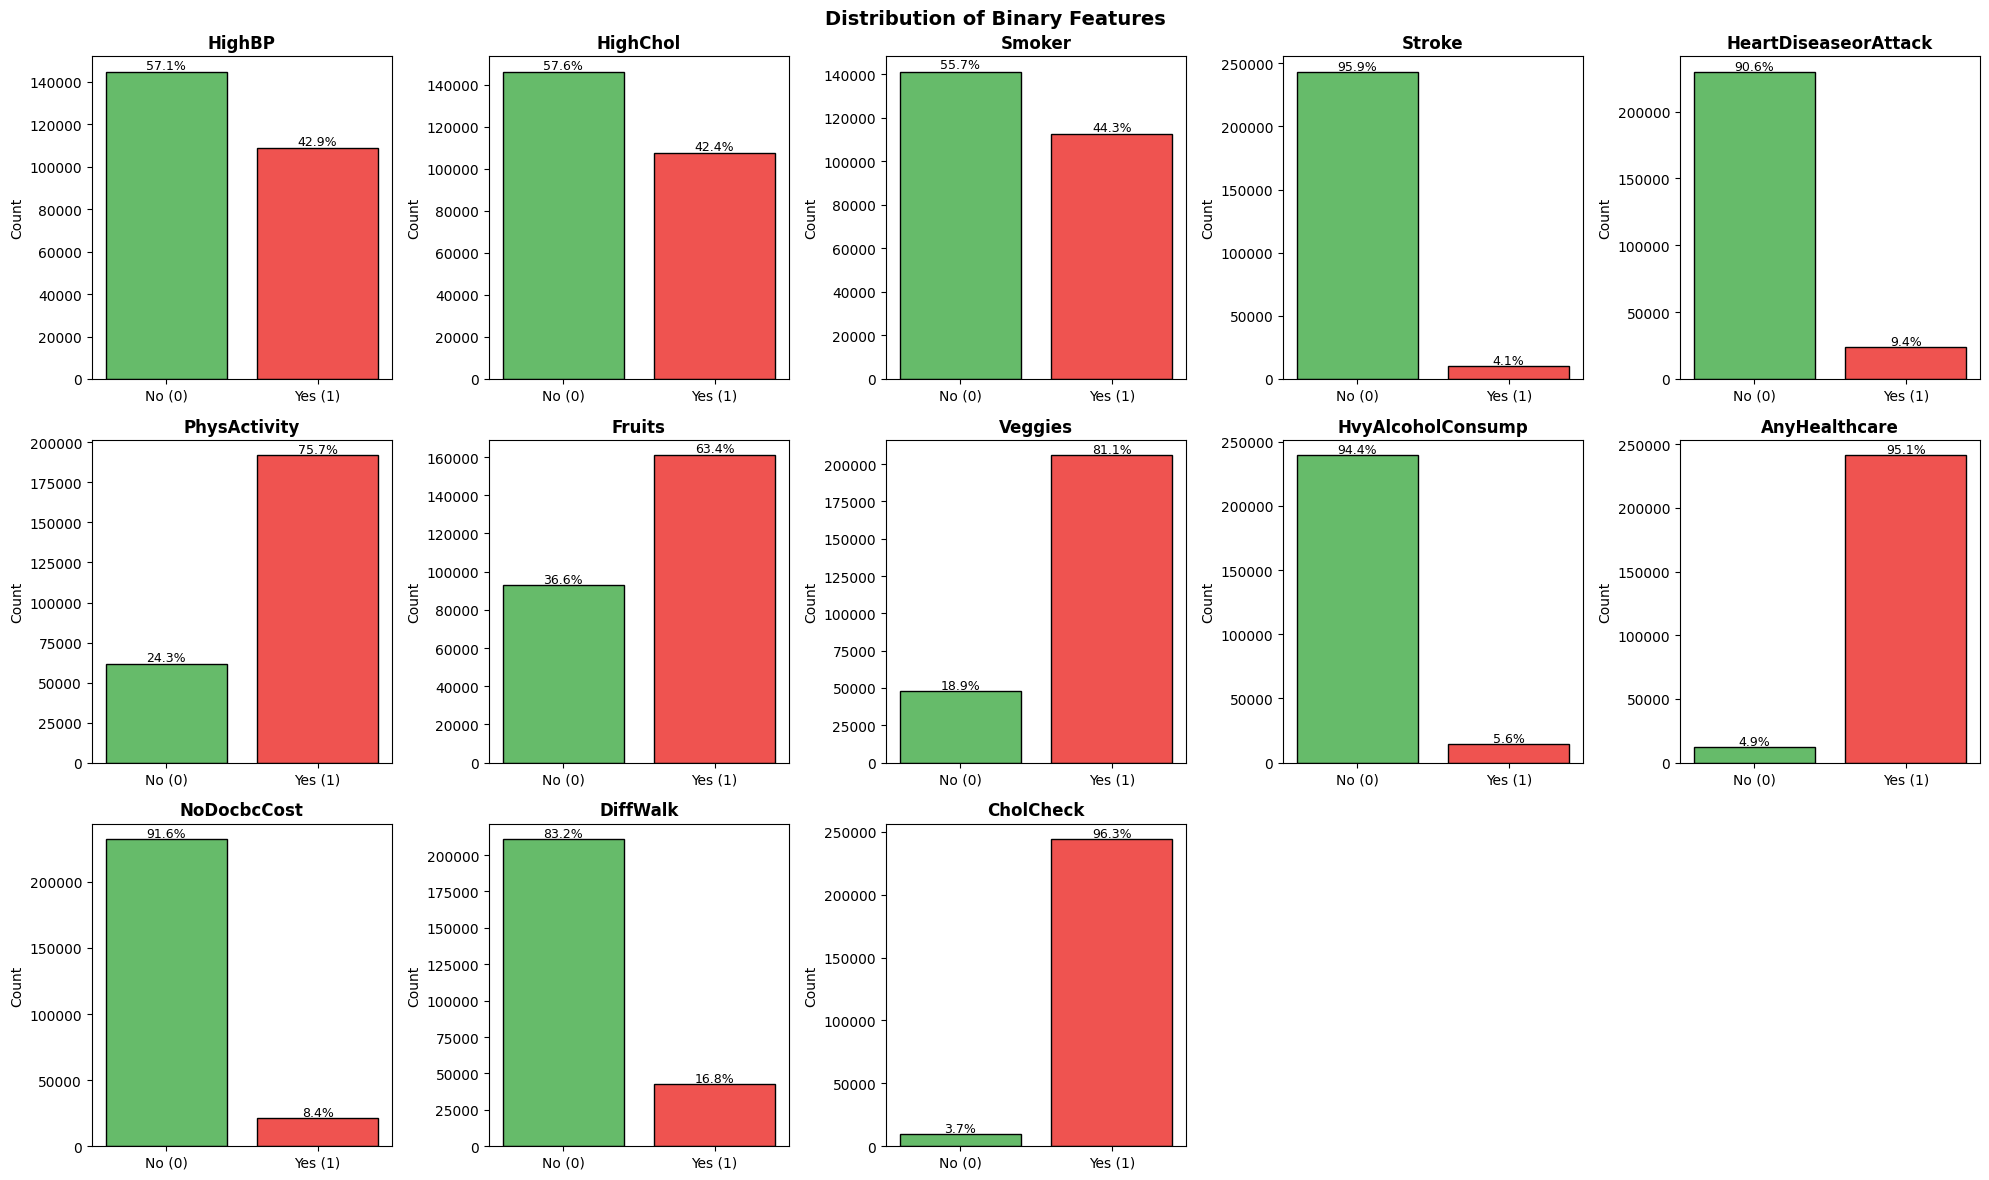

In [135]:
binary_cols = ['HighBP', 'HighChol', 'Smoker', 'Stroke', 'HeartDiseaseorAttack',
               'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump',
               'AnyHealthcare', 'NoDocbcCost', 'DiffWalk', 'CholCheck']

fig, axes = plt.subplots(3, 5, figsize=(20, 12))
axes = axes.flatten()

for i, col in enumerate(binary_cols):
    counts = df_USA_BRFSS[col].value_counts()
    axes[i].bar(['No (0)', 'Yes (1)'], [counts.get(0, 0), counts.get(1, 0)],
                color=['#66BB6A', '#EF5350'], edgecolor='black')
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_ylabel('Count')
    total = len(df_USA_BRFSS)
    for j, val in enumerate([counts.get(0, 0), counts.get(1, 0)]):
        axes[i].text(j, val + 1500, f'{val/total*100:.1f}%', ha='center', fontsize=9)

for j in range(len(binary_cols), len(axes)):
    axes[j].axis('off')

plt.suptitle('Distribution of Binary Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## **Indonesia Dataset Profiling**

### **Dimensions and Attributes**  
  
We check how many rows (observations) and list out columns (attributes) which are in the dataset to get a sense of its scale and complexity.

In [136]:
num_rows = df_Indonesia.shape[0]
num_cols = df_Indonesia.shape[1]
print(f"Number of rows: {num_rows}")
print(f"Number of columns: {num_cols}")
print(f"\nDataset Columns:")
for i in df_Indonesia.columns:
  print("- "+ i)

Number of rows: 100000
Number of columns: 9

Dataset Columns:
- gender
- age
- hypertension
- heart_disease
- smoking_history
- bmi
- HbA1c_level
- blood_glucose_level
- diabetes


### **Missing/NULL values**

We check for missing data that might need imputation (mean, median, mode) or removal depending on severity and feature importance.

In [137]:
print(f"This dataset contains missing/NULL values: {df_Indonesia.isnull().any().any()}")
print(f"No missing values were detected so no imputation is required")

This dataset contains missing/NULL values: False
No missing values were detected so no imputation is required


While initial profiling indicates zero missing or standard NULL values, closer inspection reveals that the categorical feature smoking_history contains a "No Info" category.

This dummy value will need to be explicitly addressed during the Data Cleaning phase—either via imputation or by treating it as a distinct categorical feature, depending on its prevalence.

### **Data types**
It provides a strong mix of continuous clinical metrics (Age, BMI, HbA1c, blood glucose) and categorical risk factors (Gender, smoking history, hypertension, heart disease).

In [153]:
print("Data types before conversion:")
display(df_Indonesia.dtypes)

# Convert categorical columns to category dtype
cat_cols = ['gender', 'smoking_history']
for col in cat_cols:
    df_Indonesia[col] = df_Indonesia[col].astype('category')

print("\nData types after conversion:")
display(df_Indonesia.dtypes)

Data types before conversion:


,0
gender,category
age,float64
hypertension,int64
heart_disease,int64
smoking_history,category
bmi,float64
HbA1c_level,float64
blood_glucose_level,int64
diabetes,int64



Data types after conversion:


,0
gender,category
age,float64
hypertension,int64
heart_disease,int64
smoking_history,category
bmi,float64
HbA1c_level,float64
blood_glucose_level,int64
diabetes,int64


### **Class Balance for Target variable**

We visualize the target variable (diabetes) using a bar and pie chart to examine class imbalance. The target variable here is highly imbalanced, with the vast majority of records belonging to "No Diabetes" .

Because overall incidence rate of diabetes in a general population is relatively low, this reflects real-world distributions. However, from a machine learning perspective, training on this data without intervention will result in a model biased toward negative predictions.

Resampling techniques (such as undersampling the majority class or oversampling the minority class) or reduction of dataset weight in final prediciton model will be essential.

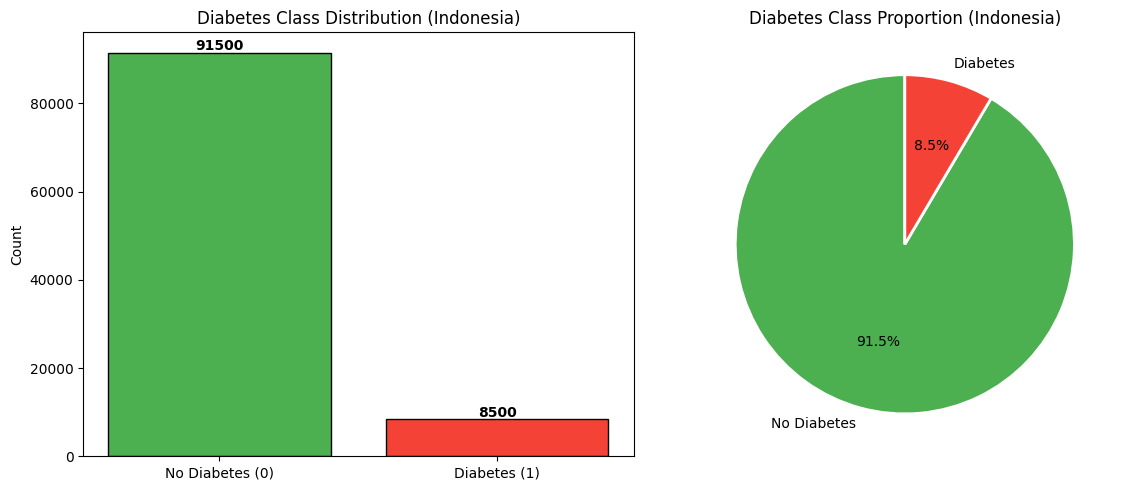

In [154]:
vc = df_Indonesia['diabetes'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

bars = axes[0].bar(['No Diabetes (0)', 'Diabetes (1)'],
                   [vc.get(0, 0), vc.get(1, 0)],
                   color=['#4CAF50', '#F44336'], edgecolor='black')
axes[0].set_title('Diabetes Class Distribution (Indonesia)')
axes[0].set_ylabel('Count')
for bar, val in zip(bars, [vc.get(0, 0), vc.get(1, 0)]):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 500, val, ha='center', fontweight='bold')

axes[1].pie([vc.get(0, 0), vc.get(1, 0)],
            labels=['No Diabetes', 'Diabetes'],
            colors=['#4CAF50', '#F44336'], autopct='%1.1f%%',
            wedgeprops={'edgecolor': 'white', 'linewidth': 2}, startangle=90)
axes[1].set_title('Diabetes Class Proportion (Indonesia)')
plt.tight_layout()
plt.show()

### **Exploration of Variables**

We use histograms to see how numerical measures like age, bmi, HbA1c_level, and blood_glucose_level are distributed.

We visualise the proportion of binary health indicators like hypertension and heart_disease via bar charts.

Certain categorical variables, specifically smoking_history, contain ambiguous categories like "No Info", which will require careful handling or encoding during the data preparation phase.

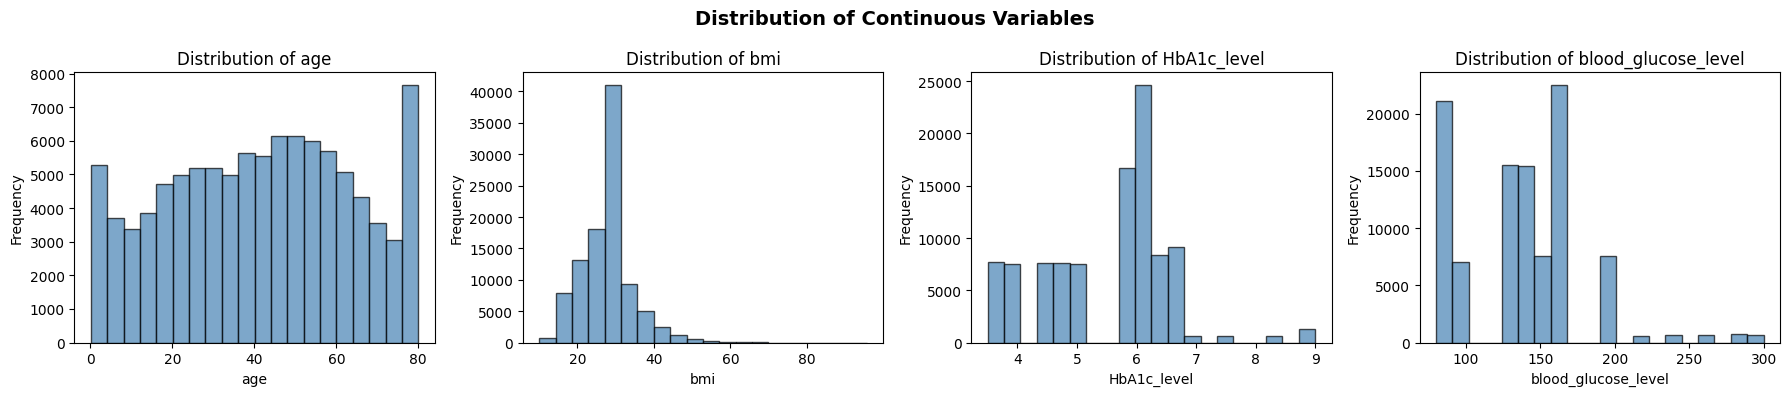

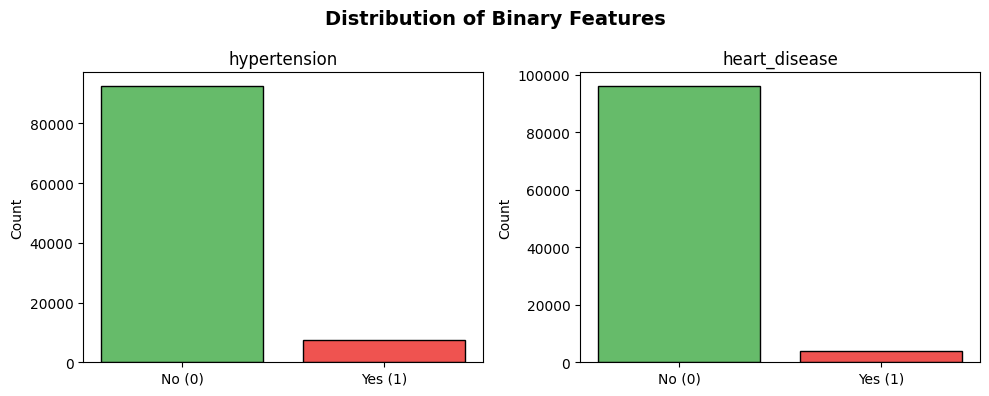

In [155]:
continuous_cols = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
axes = axes.flatten()
for i, col in enumerate(continuous_cols):
    axes[i].hist(df_Indonesia[col].dropna(), bins=20, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
plt.suptitle('Distribution of Continuous Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

binary_cols = ['hypertension', 'heart_disease']
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes = axes.flatten()
for i, col in enumerate(binary_cols):
    counts = df_Indonesia[col].value_counts()
    axes[i].bar(['No (0)', 'Yes (1)'],
                [counts.get(0, 0), counts.get(1, 0)],
                color=['#66BB6A', '#EF5350'], edgecolor='black')
    axes[i].set_title(col)
    axes[i].set_ylabel('Count')
plt.suptitle('Distribution of Binary Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## **Pima Indians Dataset Profiling**

### **Dimensions and Attributes**  
  
We check how many rows (observations) and list out columns (attributes) which are in the dataset to get a sense of its scale and complexity.

In [138]:
num_rows = df_pima.shape[0]
num_cols = df_pima.shape[1]
print(f"Number of rows: {num_rows}")
print(f"Number of columns: {num_cols}")
print(f"\nDataset Columns:")
for i in df_pima.columns:
  print("- "+ i)

Number of rows: 768
Number of columns: 9

Dataset Columns:
- Pregnancies
- Glucose
- BloodPressure
- SkinThickness
- Insulin
- BMI
- DiabetesPedigreeFunction
- Age
- Outcome


### **Missing/NULL values**

We check for missing data that might need imputation (mean, median, mode) or removal depending on severity and feature importance.

This dataset contains explicit missing/NULL values: False
Zeros found in non-binary attributes (%):
Glucose           0.651042
BloodPressure     4.557292
SkinThickness    29.557292
Insulin          48.697917
BMI               1.432292
dtype: float64

 Outcome
0    0.651
1    0.349
Name: proportion, dtype: float64


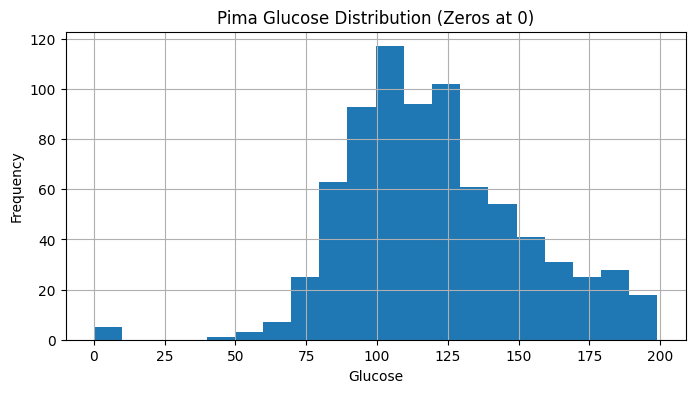

In [167]:
print(f"This dataset contains explicit missing/NULL values: {df_pima.isnull().any().any()}")
print("Zeros found in non-binary attributes (%):")
zeros_pct = (df_pima[['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']] == 0).mean() * 100
print(zeros_pct)

print(f"\n",df_pima['Outcome'].value_counts(normalize=True).round(3))

plt.figure(figsize=(8,4))
df_pima['Glucose'].hist(bins=20)
plt.xlabel('Glucose')
plt.ylabel('Frequency')
plt.title('Pima Glucose Distribution (Zeros at 0)')
plt.show()

While the dataset registers False for standard NULL values, profiling reveals explicit missing data encoded as zeroes in biological measurements which are physiologically impossible and must be treated as missing values.

### **Data types**
The dataset consists entirely of numerical, clinical-grade measurements.

It includes a unique continuous feature, the DiabetesPedigreeFunction, which mathematically quantifies genetic predisposition.

In [161]:
print("Data types:")
display(df_pima.dtypes)
# All are numeric natively, no type conversion required for exploration

Data types:


,0
Pregnancies,int64
Glucose,int64
BloodPressure,int64
SkinThickness,int64
Insulin,int64
BMI,float64
DiabetesPedigreeFunction,float64
Age,int64
Outcome,int64


### **Class Balance for Target variable**

We visualize the target variable (diabetes) using a bar and pie chart to examine class imbalance. In this case, there is moderate class imbalance.

While this imbalance is not as extreme as seen in general population datasets, it is still significant enough that it should be monitored during model evaluation.

The higher-than-average baseline prevalence of diabetes in this specific demographic explains why the minority class is still relatively well-represented.

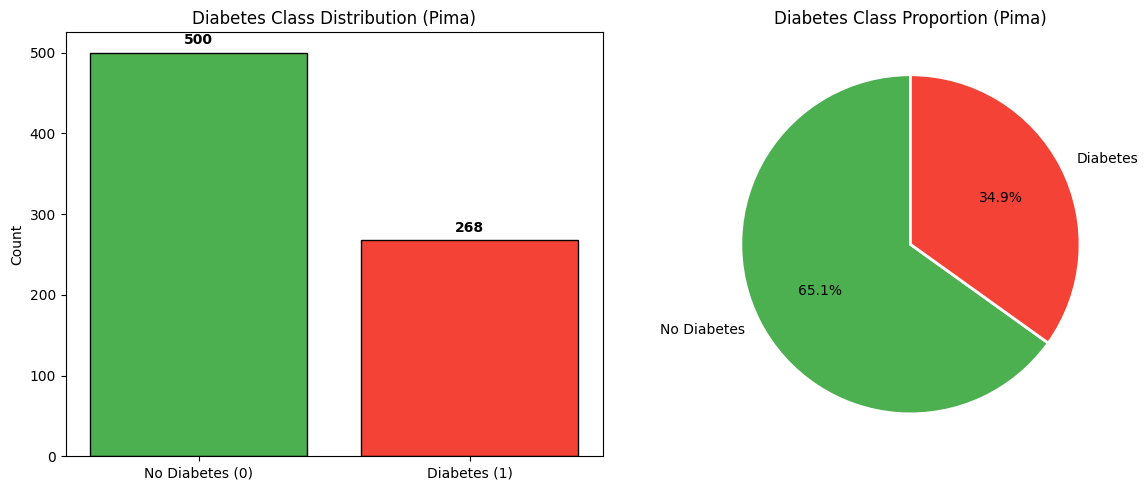

In [162]:
vc = df_pima['Outcome'].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

bars = axes[0].bar(['No Diabetes (0)', 'Diabetes (1)'],
                   [vc.get(0, 0), vc.get(1, 0)],
                   color=['#4CAF50', '#F44336'], edgecolor='black')
axes[0].set_title('Diabetes Class Distribution (Pima)')
axes[0].set_ylabel('Count')
for bar, val in zip(bars, [vc.get(0, 0), vc.get(1, 0)]):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 10, val, ha='center', fontweight='bold')

axes[1].pie([vc.get(0, 0), vc.get(1, 0)],
            labels=['No Diabetes', 'Diabetes'],
            colors=['#4CAF50', '#F44336'], autopct='%1.1f%%',
            wedgeprops={'edgecolor': 'white', 'linewidth': 2}, startangle=90)
axes[1].set_title('Diabetes Class Proportion (Pima)')
plt.tight_layout()
plt.show()

### **Exploration of Variables**

We use histograms to see how numerical measures are distributed.

Here, outliers due to zeroes representing Null value are clearly seen. This could affect resulting statistics like mean, median if not handled early.

The demographic scope is highly restricted, representing only females aged 21 and older of Pima Indian heritage, which limits the model's generalizability to broader populations.

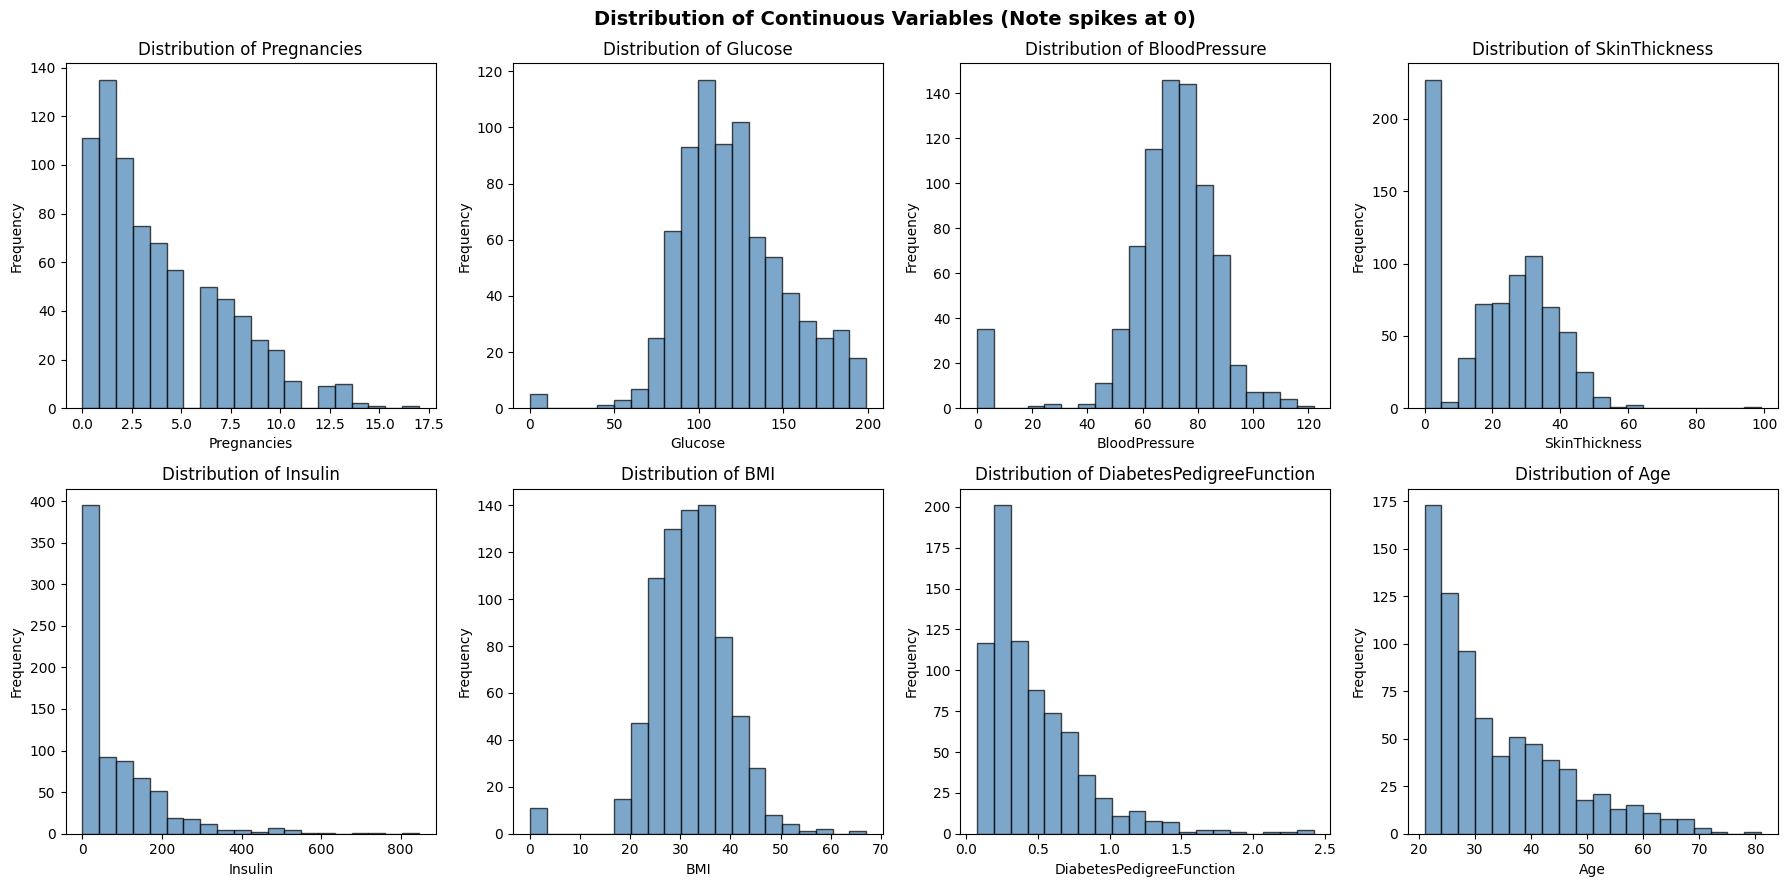

In [163]:
continuous_cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
                   'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()
for i, col in enumerate(continuous_cols):
    # We plot the raw data, which will visually reveal the physiological 0s
    axes[i].hist(df_pima[col].dropna(), bins=20, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')
plt.suptitle('Distribution of Continuous Variables (Note spikes at 0)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## **USA NHANES Dataset Profiling**

### **Dimensions and Attributes**  
  
We check how many rows (observations) and list out columns (attributes) which are in the dataset to get a sense of its scale and complexity.

In [142]:
num_rows = df_USA_NHANES.shape[0]
num_cols = df_USA_NHANES.shape[1]
print(f"Number of rows: {num_rows}")
print(f"Number of columns: {num_cols}")
print(f"\nDataset Columns:")
for i in df_USA_NHANES.columns:
  print("- "+ i)

Number of rows: 9813
Number of columns: 16

Dataset Columns:
- patient_id
- age_years
- gender_code
- bmi
- systolic_bp
- diastolic_bp
- total_cholesterol
- diabetes_status
- coronary_heart_disease
- heart_attack
- current_smoker_status
- taking_bp_meds
- taking_cholesterol_meds
- vigorous_work_activity
- vigorous_recreational_activity
- moderate_work_activity


This dataset is the result of an inner join on the primary key patient_id (`SEQN`). While this reduces the overall row count compared to the raw data, it yields a highly robust, multi-dimensional dataset containing both objective clinical measurements (e.g., bmi, total_cholesterol, systolic_bp) and subjective lifestyle factors.

### **Missing/NULL values**

We check for missing data that might need imputation (mean, median, mode) or removal depending on severity and feature importance.

In [175]:
missing_values = df_USA_NHANES.isnull().sum()
print(f"This dataset contains missing/NULL values: {df_USA_NHANES.isnull().any().any()}")
print("Missing values per column:\n", missing_values[missing_values > 0])

This dataset contains missing/NULL values: True
Missing values per column:
 bmi                                758
systolic_bp                       2641
diastolic_bp                      2641
total_cholesterol                 2189
diabetes_status                    392
coronary_heart_disease            4225
heart_attack                      4225
current_smoker_status             7323
taking_bp_meds                    8044
taking_cholesterol_meds           3547
vigorous_work_activity            2863
vigorous_recreational_activity    2864
moderate_work_activity            2863
dtype: int64


In [176]:
# Function to flag common dummy values across numerical/categorical survey data
def check_dummy_values(df, columns):
    for col in columns:
        # Check for values commonly used as dummy codes in NHANES
        dummies = df[df[col].isin([7, 9, 77, 99, 777, 999])][col].value_counts()
        if not dummies.empty:
            print(f"Dummy values found in '{col}':\n{dummies}\n")

# Check the questionnaire-based columns for these dummies
questionnaire_cols = ['diabetes_status', 'coronary_heart_disease', 'heart_attack',
                      'current_smoker_status', 'taking_bp_meds', 'taking_cholesterol_meds']
print("--- Disguised Missing Values (Refused/Don't Know) ---")
check_dummy_values(df_USA_NHANES, questionnaire_cols)

--- Disguised Missing Values (Refused/Don't Know) ---
Dummy values found in 'diabetes_status':
diabetes_status
9.0    5
7.0    1
Name: count, dtype: int64

Dummy values found in 'coronary_heart_disease':
coronary_heart_disease
9.0    16
Name: count, dtype: int64

Dummy values found in 'heart_attack':
heart_attack
9.0    3
Name: count, dtype: int64

Dummy values found in 'taking_bp_meds':
taking_bp_meds
9.0    1
Name: count, dtype: int64

Dummy values found in 'taking_cholesterol_meds':
taking_cholesterol_meds
9.0    36
Name: count, dtype: int64



**Standard Missing Values (NaN):** Objective physical and lab measurements may contain standard NaN values if a specific test was not completed or was deemed invalid by the lab.

**Disguised Dummy Values:** The questionnaire-based columns (such as coronary_heart_disease, current_smoker_status, taking_bp_meds, and activity levels) utilize numerical dummy values to represent non-answers.

Specifically, values like 7 or 77 represent "Refused", while 9 or 99 represent "Don't Know".

If fed into a machine learning model as-is, the model will treat these as large numerical weights rather than missing categorical data. These must be identified and mapped to NaN prior to modeling.

### **Data types**
The NHANES dataset primarily uses numerical codes (like 1, 2, 3, 7, 9) rather than "Yes"/"No" strings.



In [187]:
print("Data types before conversion:")
display(df_USA_NHANES.dtypes)

# 1. Convert categorical Yes(1)/No(2) columns to binary (0 = No, 1 = Yes)
binary_mapping = {1: 1, 2: 0}
diabetes_mapping = {1: 1, 2: 0, 3: 1} # Assuming borderline (3) is treated as positive/risk. Adjust if needed.

yes_no_cols = ['coronary_heart_disease', 'heart_attack', 'taking_bp_meds', 'taking_cholesterol_meds']

for col in yes_no_cols:
    if col in df_USA_NHANES.columns:
        df_USA_NHANES[col] = df_USA_NHANES[col].map(binary_mapping)

# Map diabetes status separately due to the 'Borderline' (3) category
if 'diabetes_status' in df_USA_NHANES.columns:
    df_USA_NHANES['diabetes_status'] = df_USA_NHANES['diabetes_status'].map(diabetes_mapping)


# 2. Convert categorical columns to 'category' dtype
# NHANES uses numerical codes for categories (e.g., gender_code 1=Male, 2=Female)
cat_cols = ['gender_code', 'current_smoker_status', 'coronary_heart_disease',
            'heart_attack', 'taking_bp_meds', 'taking_cholesterol_meds', 'diabetes_status']

for col in cat_cols:
    if col in df_USA_NHANES.columns:
        df_USA_NHANES[col] = df_USA_NHANES[col].astype('category')

print("\nData types after conversion:")
display(df_USA_NHANES.dtypes)

Data types before conversion:


,0
patient_id,int64
age_years,int64
gender_code,category
bmi,float64
systolic_bp,float64
diastolic_bp,float64
total_cholesterol,float64
diabetes_status,category
coronary_heart_disease,category
heart_attack,category



Data types after conversion:


,0
patient_id,int64
age_years,int64
gender_code,category
bmi,float64
systolic_bp,float64
diastolic_bp,float64
total_cholesterol,float64
diabetes_status,category
coronary_heart_disease,category
heart_attack,category


### **Class Balance for Target variable**

We visualize the target variable (diabetes_status) (derived from DIQ010), using a bar and pie chart to examine class imbalance. In this case, the target variable,  is heavily imbalanced.

In the NHANES coding scheme, this column contains multiple classes:
* 1 = Yes
* 2 = No
* 3 = Borderline (Pre-diabetes)
* 7 / 9 = Refused / Don't Know

The vast majority of records will fall into the 2 (No Diabetes) category, accurately reflecting general population health statistics.

We will need to make a structural decision regarding class 3 (Borderline)depending on our clinical predictive goal. Finally, because of the heavy skew towards class 2, techniques such as SMOTE, undersampling, or adjusting class weights will be necessary to ensure the model does not become biased toward predicting the majority class.

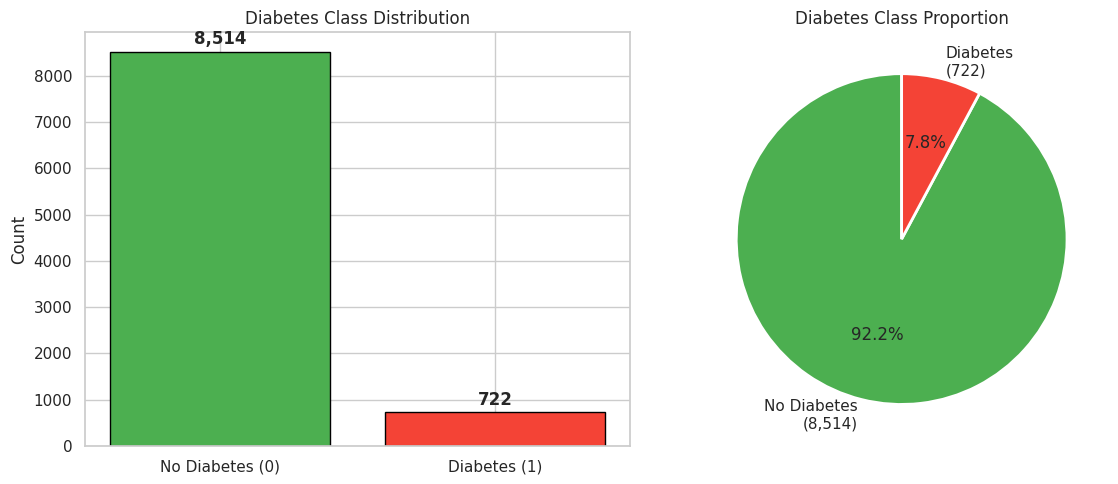

In [181]:
diabetes_mapping = {1: 'Diabetes (1)', 2: 'No Diabetes (0)', 3: 'Borderline (3)'}

# Apply mapping and drop unmapped values (like 7 or 9) to keep the visualization clean
mapped_target = df_USA_NHANES['diabetes_status'].map(diabetes_mapping).dropna()
vc = mapped_target.value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

val_no_diab = vc.get('No Diabetes (0)', 0)
val_diab = vc.get('Diabetes (1)', 0)

# Bar chart
bars = axes[0].bar(['No Diabetes (0)', 'Diabetes (1)'],
                   [val_no_diab, val_diab],
                   color=['#4CAF50', '#F44336'], edgecolor='black')
axes[0].set_ylabel('Count')
axes[0].set_title('Diabetes Class Distribution')

for bar, val in zip(bars, [val_no_diab, val_diab]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + (val_no_diab * 0.02),
                 f'{val:,}', ha='center', fontweight='bold')

# Pie chart
axes[1].pie([val_no_diab, val_diab],
            labels=[f'No Diabetes\n({val_no_diab:,})', f'Diabetes\n({val_diab:,})'],
            colors=['#4CAF50', '#F44336'], autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Diabetes Class Proportion')

plt.tight_layout()
plt.show()

### **Exploration of Variables**

We use histograms to see how numerical measures like age_years, bmi, systolic_bp, total_cholesterol are distributed.

We visualise the proportion of binary health indicators like coronary_heart_disease and heart_attack via bar charts.

BMI is notoriously right-skewed in USA health datasets. Most people cluster in the 25–30 range, but there is a long tail of individuals with very high BMIs. We might need to apply a log transformation or Robust Scaling to normalize this feature.

Systolic_bp and total_cholesterol extreme upper-bound outliers. We have to check if they are biologically possible

age_years in NHANES is often capped at 80 (meaning anyone 80 or older is recorded as 80).

For coronary_heart_disease and heart_attack, because these conditions are rare, there may not be enough positive cases for a model to establish a strong correlation with diabetes unless the dataset is very large.

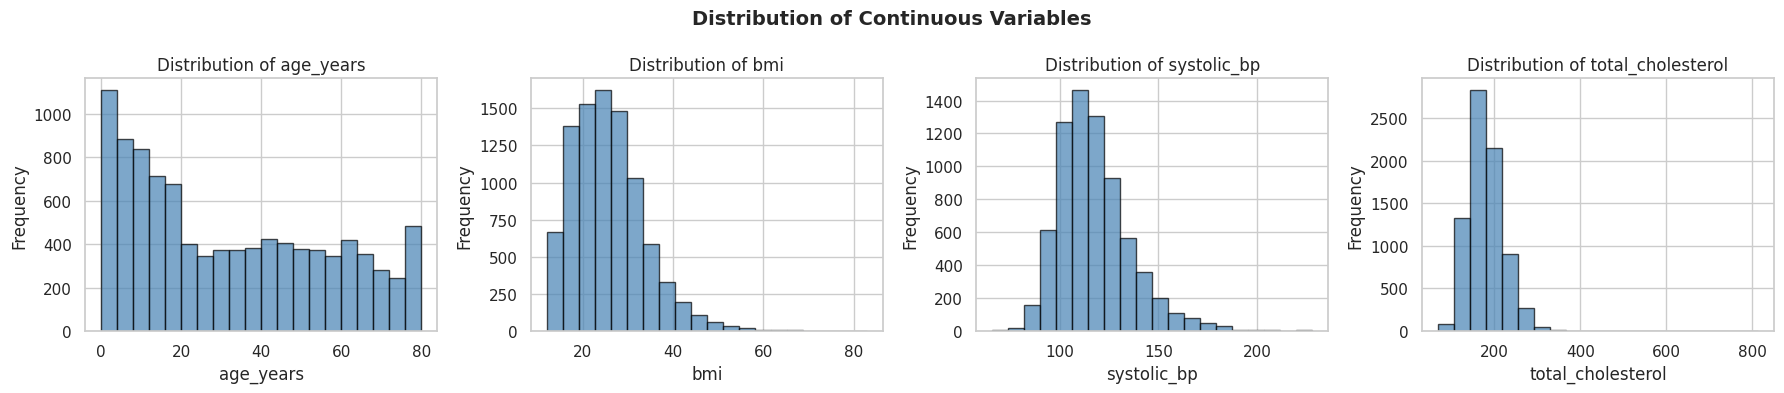

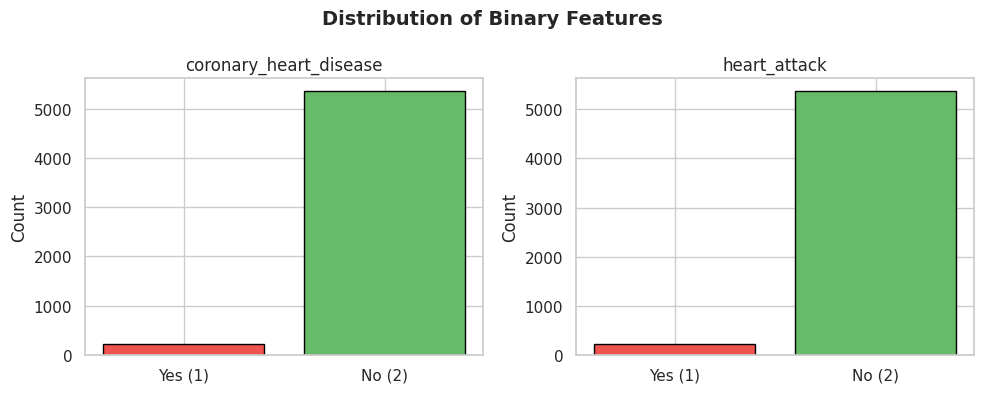

In [185]:
continuous_cols = ['age_years', 'bmi', 'systolic_bp', 'total_cholesterol']

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
axes = axes.flatten()

for i, col in enumerate(continuous_cols):
    axes[i].hist(df_USA_NHANES[col].dropna(), bins=20, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.suptitle('Distribution of Continuous Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

binary_cols = ['coronary_heart_disease', 'heart_attack']

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes = axes.flatten()

for i, col in enumerate(binary_cols):
    counts = df_USA_NHANES[col].value_counts()
    axes[i].bar(['Yes (1)', 'No (2)'],
    [counts.get(1, 0), counts.get(2, 0)],
    color=['#EF5350', '#66BB6A'], edgecolor='black')

    axes[i].set_title(col)
    axes[i].set_ylabel('Count')

plt.suptitle('Distribution of Binary Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## **Conclusion of Datasets**

After conducting initial data profiling across the six prospective datasets, we have elected to drop the Bangladesh, USA BRFSS, and Pima Indians datasets.

The Bangladesh dataset was excluded due to its extremely small sample size (520 rows) and heavy reliance on subjective, self-reported symptoms rather than clinical metrics.

The USA BRFSS dataset was dropped because it consists entirely of survey-based, self-reported data subject to recall bias and contains a high volume of disguised missing values (e.g., "Refused" or "Don't Know") across its categorical fields.

Finally, the Pima Indians dataset was dropped due to its highly restricted demographic scope (only adult females of Pima Indian heritage) and small sample size (768 rows), which severely limits the global generalizability of any trained models. Furthermore, it contains known data quality issues where missing biological metrics are recorded as disguised zeros (e.g., BMI or Blood Pressure of 0).

In contrast, the retained datasets (India, Indonesia, and NHANES) provide a much stronger foundation for our project. They offer a robust balance of objective clinical measurements (e.g., lab-tested blood glucose, BMI, HbA1c), cleaner data structures, and sufficiently large, diverse sample sizes that are crucial for training reliable and generalized predictive models.

# **DATA PREPARATION (PROCESS)**

After careful evaluation of the six initial datasets, we have finalised on the following three datasets to clean, sturcture, and enrich before mergining into one unified dataset for our data analysis

## **India Dataset Preparation**

## **Indonesia Dataset Preparation**

## **USA NHANES Dataset Preparation**

## **Merge of Final Dataset**
Before merging the datasets, we profiled the target variables across all sources to establish inclusion dependencies. We verified that the categorical domains for our selected cohesive features (e.g., `gender` as 0/1, `diabetes` as 0/1) match across the three selected datasets. This ensures that the union of these datasets will not create conflicting or fragmented categorical spaces.

In [151]:
#Insert Merge code here